# Semla distance analysis

For cell type radial distance, also can be used for cluster types.

# Setting up

In [6]:
library(Seurat)
library(SeuratDisk)
library(semla)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following object is masked from ‘package:base’:

    intersect


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


semla v1.3.1

Authors: Ludvig Larsson and Lovisa Franzen



# Preparing metadata

In [ ]:
obj<-readRDS('/gpfs/data/proteomics/data/Cervical_mIF/output/seurat_objects/Cervical_srtv5_merged_obj_umap.rds')
immune_metadata<-read.csv('/gpfs/data/proteomics/data/Cervical_mIF/output/seurat_objects/immune/Cervical_immune_v5_metadata.csv')
tumor_metadata<-read.csv('/gpfs/data/proteomics/data/Cervical_mIF/output/seurat_objects/Tumor/Cervical_tumor_v4_metadata.csv')

In [ ]:
obj$immune<-ifelse(obj$Final.cell.type == "Tumor" | obj$Final.cell.type == "Endothelial" | obj$Final.cell.type=="Stromal_Undefined" |obj$Final.cell.type=="Unknown", yes=FALSE, no=TRUE)
tumor_meta<-tumor_metadata[1:2882447,]


In [ ]:
tumor_metadata$Fine.cell.type<-tumor_metadata$Final.cell.type
tumor_metadata$Fine.cell.type[tumor_metadata$cycling_cluster=="High_cycling"]<-"Cycling_Tumor"

immune_metadata$Fine.cell.type<-immune_metadata$Final.cell.type
immune_metadata$Fine.cell.type[immune_metadata$CD45RO_cluster=="High_activation"]<-paste0("Activated_", immune_metadata$Final.cell.type[immune_metadata$CD45RO_cluster=="High_activation"])

meta_vector<-c(tumor_meta$Fine.cell.type, immune_metadata$Fine.cell.type)
meta_vector<-c(meta_vector, obj$Final.cell.type[obj$immune==FALSE & obj$Final.cell.type!="Tumor"])
names(meta_vector)<-c(tumor_meta$X, rownames(immune_metadata), colnames(obj)[obj$immune==FALSE & obj$Final.cell.type!="Tumor"])
meta_vector[meta_vector=="Unknown" | meta_vector=="Stromal_Undefined"] <-"Stromal_Undefined_Unknown"

obj<-AddMetaData(obj, metadata=meta_vector, col.name="Fine.cell.type")
# obj$Fine.cell.type[obj$Final.cell.type=="Unknown" | meta_obj$Final.cell.typevector=="Stromal_Undefined"] <-"Stromal_Undefined_Unknown"

In [ ]:
samples_chosen<-unique(obj$orig.ident)
# split samples 
samples_chosen<-samples_chosen[8:14]
# samples_chosen<-samples_chosen[1:7] # yumi

# Fixing metadata

In [5]:
total_metadata<-read.csv('/gpfs/data/proteomics/data/Cervical_mIF/output/seurat_objects/Cervical_v5_obj_metadata_noUnknown.csv')

In [19]:
total_metadata$orig.ident<-stringr::str_pad(total_metadata$orig.ident, 5, pad=0)
rownames(total_metadata)<-total_metadata$Unnamed..0
head(total_metadata)

,Unnamed..0,orig.ident,nCount_RNA,nFeature_RNA,Age_at_Diagnosis,Stage_at_diagnosis,CPS_Score,Specimen_from_Path,Radiation_Therapy,Response,⋯,Length_of_Treatment_days,Diagnosis_Year,x,y,barcodes,RNA_snn_res.0.4,seurat_clusters,Final.cell.type,immune,Fine.cell.type
,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<int>,<int>,<dbl>,<dbl>,<chr>,<int>,<int>,<chr>,<chr>,<chr>
02433_Cell1,02433_Cell1,02433,19169.929,34,54,IV,>1,Cervical biopsy,Yes,Yes,⋯,122,2024,6515.259,3588.047,Cell1,1,1,Tumor,False,Tumor
02433_Cell2,02433_Cell2,02433,20208.610,34,54,IV,>1,Cervical biopsy,Yes,Yes,⋯,122,2024,6524.830,3587.780,Cell2,1,1,Tumor,False,Cycling_Tumor
02433_Cell3,02433_Cell3,02433,22242.868,34,54,IV,>1,Cervical biopsy,Yes,Yes,⋯,122,2024,6542.462,3586.187,Cell3,1,1,Tumor,False,Cycling_Tumor
02433_Cell4,02433_Cell4,02433,22799.357,33,54,IV,>1,Cervical biopsy,Yes,Yes,⋯,122,2024,6560.017,3586.835,Cell4,1,1,Tumor,False,Cycling_Tumor
02433_Cell5,02433_Cell5,02433,9322.615,34,54,IV,>1,Cervical biopsy,Yes,Yes,⋯,122,2024,6636.277,3585.585,Cell5,2,2,Th1,True,Th1
02433_Cell6,02433_Cell6,02433,9156.828,34,54,IV,>1,Cervical biopsy,Yes,Yes,⋯,122,2024,6429.039,3588.750,Cell6,2,2,Macrophage_CD163pos,True,Macrophage_CD163pos


In [20]:
samples_chosen<-unique(total_metadata$orig.ident)
# split samples 
# samples_chosen<-samples_chosen[8:14]
samples_chosen<-samples_chosen[c(1:5,7)] # yumi
samples_chosen

[1] "02433" "08153" "10103" "00862" "09002" "34933"

In [21]:
coords_list<-list()
for( sam in samples_chosen){
coords_list[[sam]] <- data.frame(
  barcode = rownames(total_metadata)[total_metadata$orig.ident==sam],
  x = total_metadata$x[total_metadata$orig.ident==sam],
  y = total_metadata$y[total_metadata$orig.ident==sam],
  sampleID = rep(1,times = sum(total_metadata$orig.ident==sam)),
  stringsAsFactors = FALSE
)
}

In [22]:
head(coords_list[[1]])
# head(spots)
# length(spots)          # Should be > 0
# all(spots %in% coords$barcode)  # Should be TRUE
#example format

,barcode,x,y,sampleID
,<chr>,<dbl>,<dbl>,<dbl>
1,02433_Cell1,6515.259,3588.047,1
2,02433_Cell2,6524.830,3587.780,1
3,02433_Cell3,6542.462,3586.187,1
4,02433_Cell4,6560.017,3586.835,1
5,02433_Cell5,6636.277,3585.585,1
6,02433_Cell6,6429.039,3588.750,1


In [23]:
write.csv(total_metadata, "/gpfs/home/yb2612/yb2612_fenyo/data/seurat_objects/Cervical_v5_obj_metadata_noUnknown.csv")

# Distance analysis (run as batch job)

In [ ]:
# distance analysis
for(sam in samples_chosen){
    print(paste0("Running sample: ", sam))
for(x in unique(total_metadata$Fine.cell.type[total_metadata$orig.ident==sam])){
    spots<-rownames(total_metadata)[total_metadata$Fine.cell.type==x & total_metadata$orig.ident==sam]
    head(spots)
    radial_distances <- RadialDistance(coords_list[[sam]][,1:4], spots, convert_to_microns = F, maxDist=200, remove_singletons = F)
    total_metadata[total_metadata$orig.ident==sam,paste0("r_dist_",x)]<-radial_distances
}
}

ℹ Extracting border spots from a region with 45108 spots

→   Detected 60112 spots on borders

→   Detected 45108 spots inside borders

→   Detected 153440 spots outside borders

✔ Returning radial distances

ℹ Extracting border spots from a region with 8443 spots

→   Detected 30013 spots on borders

→   Detected 8443 spots inside borders

→   Detected 190105 spots outside borders

✔ Returning radial distances

ℹ Extracting border spots from a region with 49802 spots

→   Detected 87701 spots on borders

→   Detected 49802 spots inside borders

→   Detected 148746 spots outside borders

✔ Returning radial distances

ℹ Extracting border spots from a region with 11047 spots

→   Detected 30554 spots on borders

→   Detected 11047 spots inside borders

→   Detected 187501 spots outside borders

✔ Returning radial distances

ℹ Extracting border spots from a region with 22372 spots

→   Detected 72688 spots on borders

→   Detected 22372 spots inside borders

→   Detected 176176 spots outs

In [ ]:
### STOP to regroup :)

# Cleaning distance analysis results

In [24]:
total_metadata <- read.csv("/gpfs/home/yb2612/yb2612_fenyo/data/seurat_objects/Cervical_v5_obj_metadata_1to5_7_radial_distances.csv")

In [86]:
# add empty columns for all cell types
# for(x in unique(total_metadata$Fine.cell.type)){
#     total_metadata[, paste0(x,"_dist_kmeans")]<-NULL
# }

# add empty columns for all cell types
for(x in unique(total_metadata$Fine.cell.type)){
    total_metadata[, paste0(x,"_dist_kmeans")]<-NA
}
total_metadata$orig.ident<-stringr::str_pad(total_metadata$orig.ident, 5, pad=0)

head(total_metadata)

,X,Unnamed..0,orig.ident,nCount_RNA,nFeature_RNA,Age_at_Diagnosis,Stage_at_diagnosis,CPS_Score,Specimen_from_Path,Radiation_Therapy,⋯,CD4_T_dist_kmeans,Activated_CD4_T_dist_kmeans,Activated_Exhausted_CD8_dist_kmeans,Endothelial_dist_kmeans,Activated_Neutrophil_dist_kmeans,Activated_Treg_dist_kmeans,Macrophage_CD163neg_dist_kmeans,Activated_Th1_dist_kmeans,Activated_Macrophage_CD163neg_dist_kmeans,Activated_Macrophage_CD163pos_dist_kmeans
,<chr>,<chr>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,⋯,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
1,02433_Cell1,02433_Cell1,02433,19169.929,34,54,IV,>1,Cervical biopsy,Yes,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,02433_Cell2,02433_Cell2,02433,20208.610,34,54,IV,>1,Cervical biopsy,Yes,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
3,02433_Cell3,02433_Cell3,02433,22242.868,34,54,IV,>1,Cervical biopsy,Yes,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
4,02433_Cell4,02433_Cell4,02433,22799.357,33,54,IV,>1,Cervical biopsy,Yes,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
5,02433_Cell5,02433_Cell5,02433,9322.615,34,54,IV,>1,Cervical biopsy,Yes,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
6,02433_Cell6,02433_Cell6,02433,9156.828,34,54,IV,>1,Cervical biopsy,Yes,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [87]:
samples_chosen<-unique(total_metadata$orig.ident)
# split samples 
# samples_chosen<-samples_chosen[8:14]
samples_chosen<-samples_chosen[c(1:5,7)] # yumi
samples_chosen

[1] "02433" "08153" "10103" "00862" "09002" "34933"

In [94]:
for(sam in samples_chosen){
    message("Running sample: ", sam)
    placey_placed<-as.data.frame(matrix(ncol=length(unique(total_metadata$Fine.cell.type)), nrow=sum(total_metadata$orig.ident==sam)))
    chosen_sample<- total_metadata[total_metadata$orig.ident==sam,]
    colnames(placey_placed)<-paste0(unique(total_metadata$Fine.cell.type),"_dist_kmeans")
    rownames(placey_placed)<-rownames(total_metadata)[total_metadata$orig.ident==sam]
    for(x in unique(total_metadata$Fine.cell.type[total_metadata$orig.ident==sam])){
        message("Calculating kmeans for:", x)
        placey<-kmeans(chosen_sample[chosen_sample$Fine.cell.type!=x, paste0("r_dist_", x)], centers=3)
        placey_placed[,paste0(x,"_dist_kmeans")]<-0
        placey_placed[chosen_sample$Fine.cell.type!=x, paste0(x,"_dist_kmeans")]<-placey$cluster
        placey_placed[,paste0(x,"_dist_kmeans")]<-as.character(factor(placey_placed[,paste0(x,"_dist_kmeans")],labels = c(x,"Near", "Moderately_near","Far"), levels=c(0,
                                                                                                                    which(placey$centers ==min(placey$centers)),
                                                                                                                    setdiff(1:3, c(which(placey$centers ==min(placey$centers)), which(placey$centers ==max(placey$centers)))),
                                                                                                                    which(placey$centers ==max(placey$centers)))))
    }
    total_metadata[total_metadata$orig.ident==sam, colnames(placey_placed)]<-placey_placed
}

Running sample: 02433

Calculating kmeans for:Tumor

Calculating kmeans for:Cycling_Tumor

Calculating kmeans for:Th1

Calculating kmeans for:Macrophage_CD163pos

Calculating kmeans for:Activated_B

Calculating kmeans for:Stromal_Undefined_Unknown

Calculating kmeans for:Cytotoxic_NK

Calculating kmeans for:Neutrophil

Calculating kmeans for:B

Calculating kmeans for:Exhausted_CD8

Calculating kmeans for:Treg

Calculating kmeans for:CD8_T

Calculating kmeans for:Activated_T

Calculating kmeans for:T

Calculating kmeans for:Activated_CD8_T

Calculating kmeans for:Activated_Cytotoxic_NK

Calculating kmeans for:CD4_T

Calculating kmeans for:Activated_CD4_T

Calculating kmeans for:Activated_Exhausted_CD8

Calculating kmeans for:Endothelial

Calculating kmeans for:Activated_Neutrophil

Calculating kmeans for:Activated_Treg

Calculating kmeans for:Macrophage_CD163neg

Calculating kmeans for:Activated_Th1

Calculating kmeans for:Activated_Macrophage_CD163neg

Calculating kmeans for:Activated_

In [95]:
table(total_metadata$Tumor_dist_kmeans)


          Tumor            Near Moderately_near             Far 
         680400         1058882          195291           41722 

In [99]:
sum(total_metadata$orig.ident %in% samples_chosen)

[1] 1976295

In [96]:
680400+1058882+195291+41722

[1] 1976295

In [100]:
write.csv(total_metadata, "/gpfs/home/yb2612/yb2612_fenyo/data/seurat_objects/Cervical_v5_obj_metadata_1to5_7_radial_distances_kmeans.csv")

# Plotting

In [110]:
table(total_metadata$Tumor_dist_kmeans,total_metadata$orig.ident)

                 
                   00438  00862  02433  04738  07291  07688  08153  09002
  Tumor                0 460103  47709      0      0      0  34881 123649
  Near                 0 825723 100837      0      0      0  43213  59170
  Moderately_near      0 116588  41376      0      0      0  20661   9972
  Far                  0  24534   8626      0      0      0   4865   1554
                 
                   10103  10285  28873  34933  39367  49411
  Tumor             6040      0      0   8018      0      0
  Near              6844      0      0  23095      0      0
  Moderately_near   3075      0      0   3619      0      0
  Far                673      0      0   1470      0      0

In [101]:
head(total_metadata$Fine.cell.type!=x)

[1] TRUE TRUE TRUE TRUE TRUE TRUE

In [103]:
chosen_sample <- total_metadata[total_metadata$orig.ident==samples_chosen[1],]

In [104]:
table(chosen_sample$Tumor_dist_kmeans)


          Tumor            Near Moderately_near             Far 
          47709          100837           41376            8626 

In [125]:
samples_chosen

[1] "02433" "08153" "10103" "00862" "09002" "34933"

In [ ]:
total_metadata <- read.csv("/gpfs/home/yb2612/yb2612_fenyo/data/seurat_objects/Cervical_v5_obj_metadata_total_metadata_radial_distances_kmeans.csv")

In [ ]:
library(ggplot2)
# chosen_sample <- total_metadata[total_metadata$orig.ident==samples_chosen[1],]

for(sam in samples_chosen){
    message("Plotting", sam)
    chosen_sample<- total_metadata[total_metadata$orig.ident==sam,]
    options(repr.plot.width=15, repr.plot.height=15)
    head(chosen_sample)
    rdist_plot <- ggplot(chosen_sample, aes(x=x, y=y, color=r_dist_Tumor)) + scale_color_viridis_c(option = "magma") + geom_point(size=0.3) + theme_classic()
    ggsave(paste0("/gpfs/home/yb2612/yb2612_fenyo/data/seurat_objects/plots/Cervical_v5_obj_rdist_plot.png"), plot = rdist_plot, width = 15, height = 15)
}

Plotting02433

Plotting08153



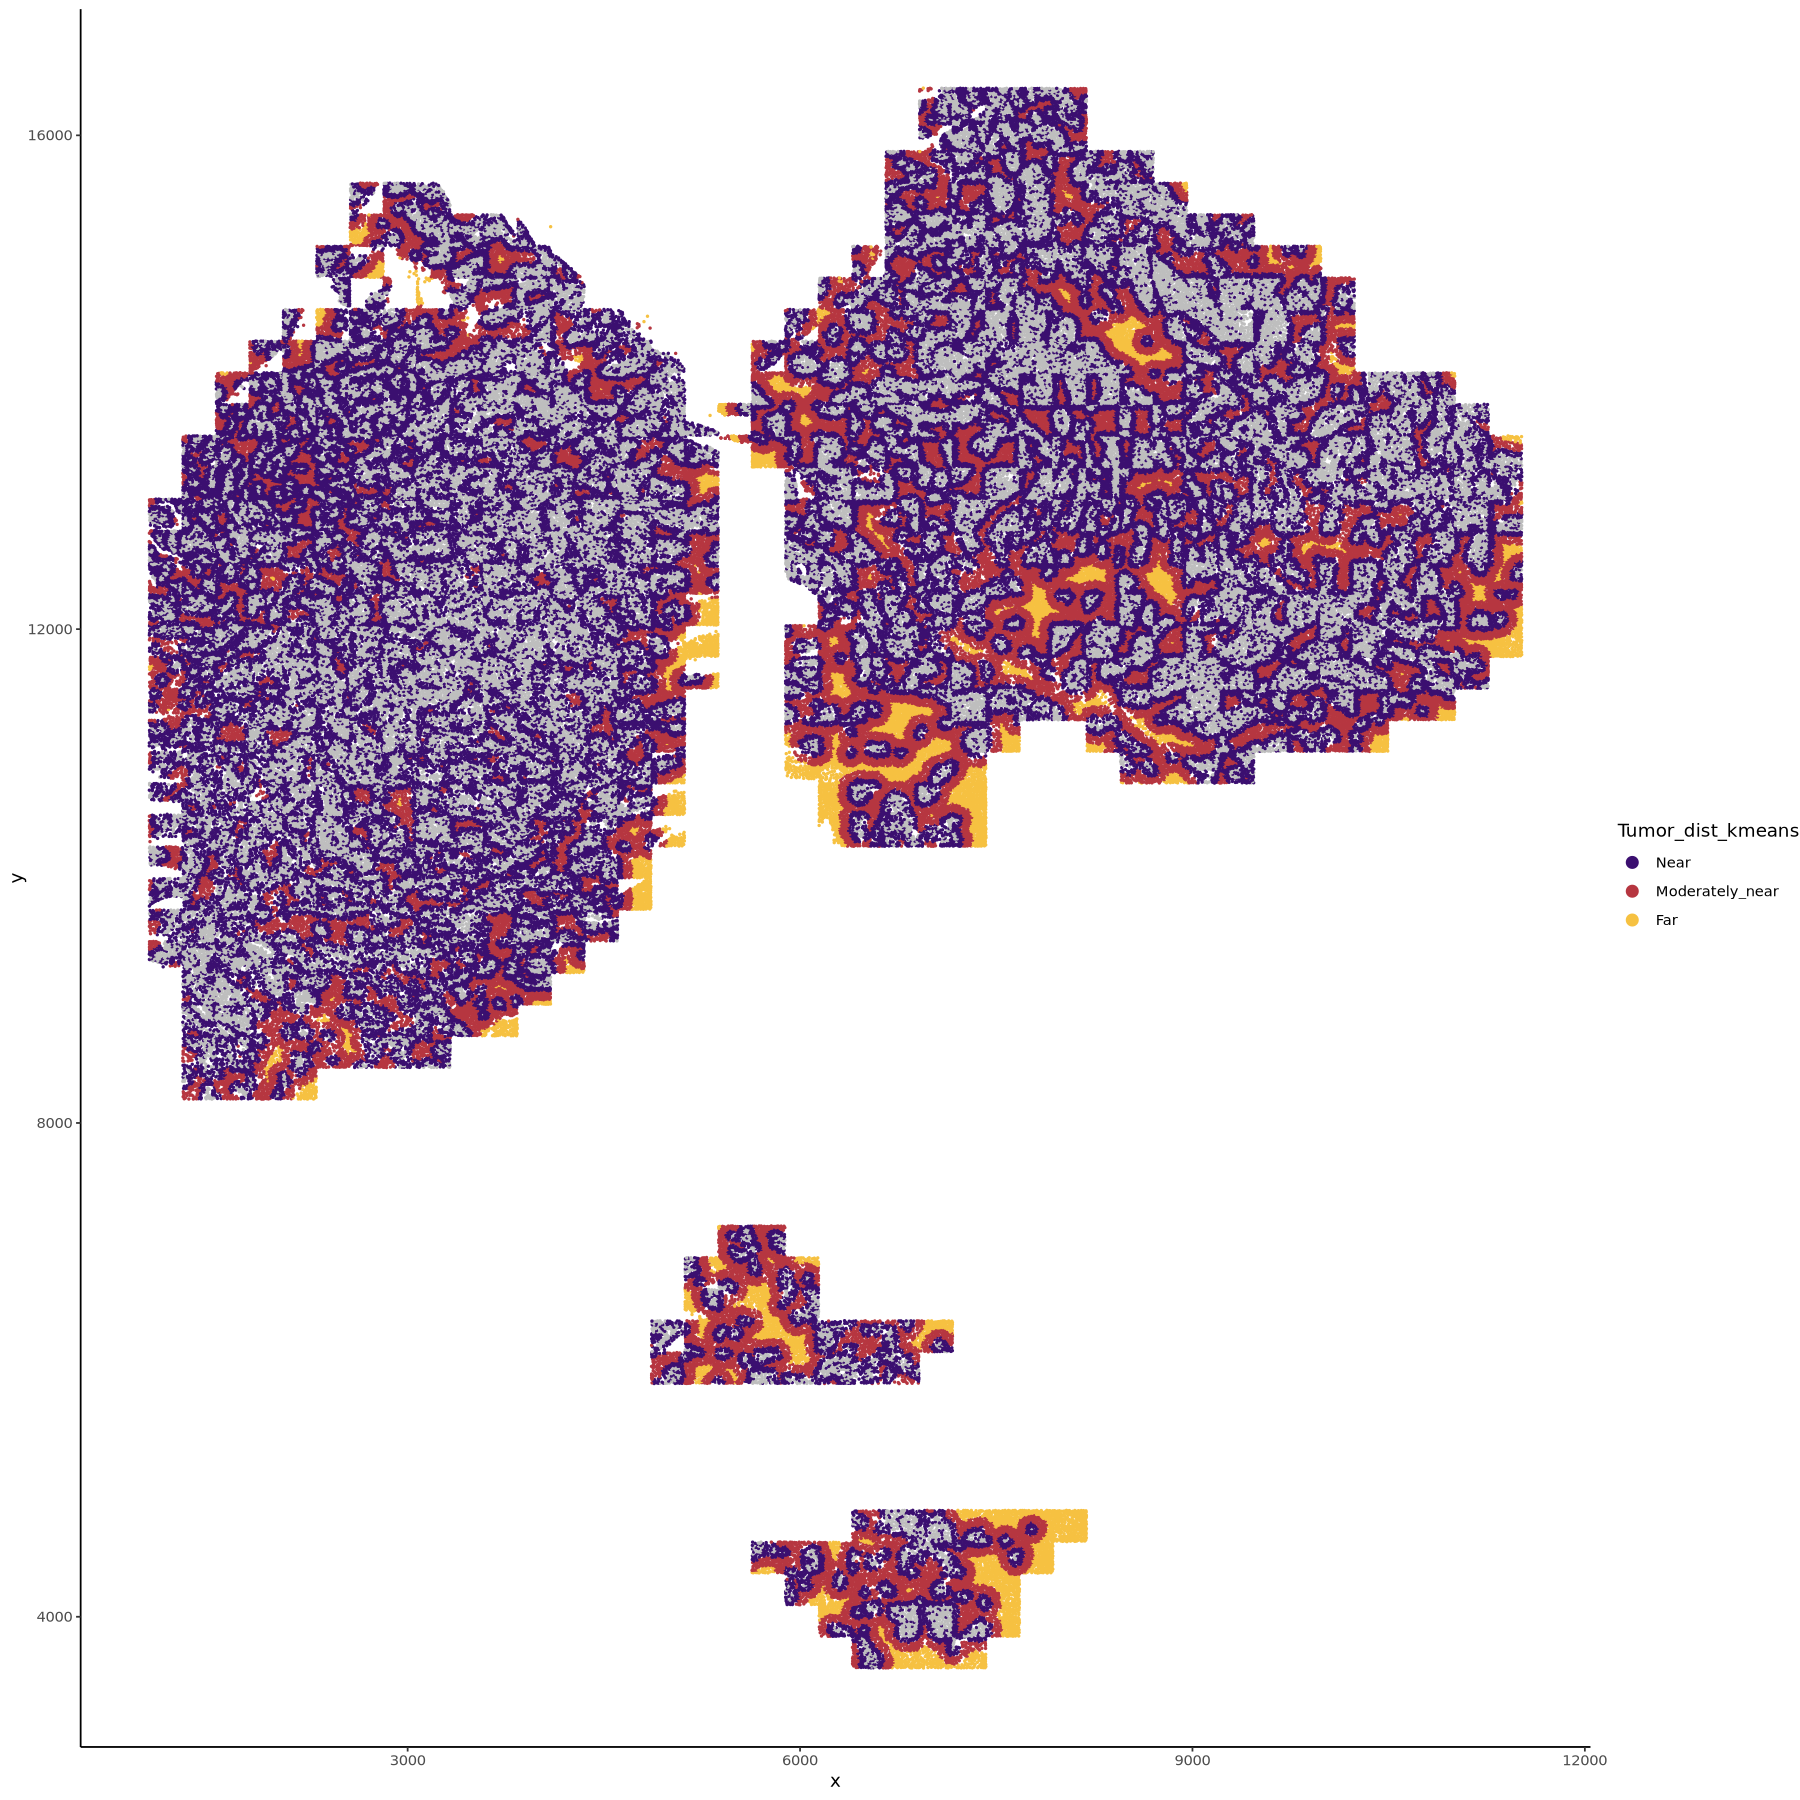

In [122]:
library(ggplot2)

cell_type_colors <- c(
  Near = "#3B0F70",              # deep purple
  Moderately_near = "#B63640",   # rich red
  Far = "#F6C141"                # warm yellow
)

ggplot(chosen_sample, aes(x = x, y = y, color = Tumor_dist_kmeans)) +
  geom_point(size = 0.3) +
  theme_classic() +
  scale_color_manual(values = cell_type_colors, na.value = "gray") +
  guides(color = guide_legend(override.aes = list(size=3)))

In [107]:
table(chosen_sample$Tumor_dist_kmeans)
table(chosen_sample$Fine.cell.type, chosen_sample$Tumor_dist_kmeans)


          Tumor            Near Moderately_near             Far 
          47709          100837           41376            8626 

                               
                                Tumor  Near Moderately_near   Far
  Activated_B                       0   311             309    78
  Activated_CD4_T                   0  1347             759   211
  Activated_CD8_T                   0  4074            2504   657
  Activated_Cytotoxic_NK            0   370             276    98
  Activated_Exhausted_CD8           0  2101            1563   306
  Activated_Macrophage_CD163neg     0   238              60     9
  Activated_Macrophage_CD163pos     0   276              90    12
  Activated_Neutrophil              0   492             283    54
  Activated_T                       0   962             442   116
  Activated_Th1                     0   168             189    53
  Activated_Treg                    0  1473             658   167
  B                                 0  4614            3260   956
  CD4_T                             0  2779            1465   414
  CD8_T                             0 12962 

In [114]:
length(unique(total_metadata$Fine.cell.type))

[1] 26

In [115]:
cell_type_colors <- c(
  Tumor = "#D60000",                        # from CHOL
  Cycling_Tumor = "#8C3BFF",                # from HNSC
  Stromal_Undefined_Unknown = "#018700",    # from KIRP
  Endothelial = "#00ACC6",                  # from PCPG
  Activated_Endothelial = "#97FF00",        # from GBM
  Neutrophil = "#573B00",                   # from LUAD
  Activated_Neutrophil = "#6B004F",         # from COADREAD
  Macrophage_CD163neg = "#FFA52F",          # from LAML
  Activated_Macrophage_CD163neg = "#FF7ED1",# from LUSC
  Macrophage_CD163pos = "#005659",          # from LUNG
  Activated_Macrophage_CD163pos = "#0000DD",# from PAAD
  CD4_T = "#00FDCF",                        # from SKCM
  Activated_CD4_T = "#A17569",              # from SARC
  CD8_T = "#BCB6FF",                        # from LGG
  Activated_CD8_T = "#95B577",              # from READ
  Treg = "#BF03B8",                         # from BLCA
  Activated_Treg = "#645474",              # from DLBC
  Th1 = "#790000",                          # from PRAD
  Activated_Th1 = "#0774D8",                # from GBMLGG
  T = "#FDF490",                            # from MESO
  Activated_T = "#004B00",                  # from KIRC
  Exhausted_CD8 = "#8E7900",                # from UCEC
  Activated_Exhausted_CD8 = "#FF7266",      # from BRCA
  B = "#EDB8B8",                            # from ESCA
  Activated_B = "#5D7E66",                  # from OV
  Cytotoxic_NK = "#9AE4FF",                 # from TGCT
  Activated_Cytotoxic_NK = "#EB0077"        # from UVM
)

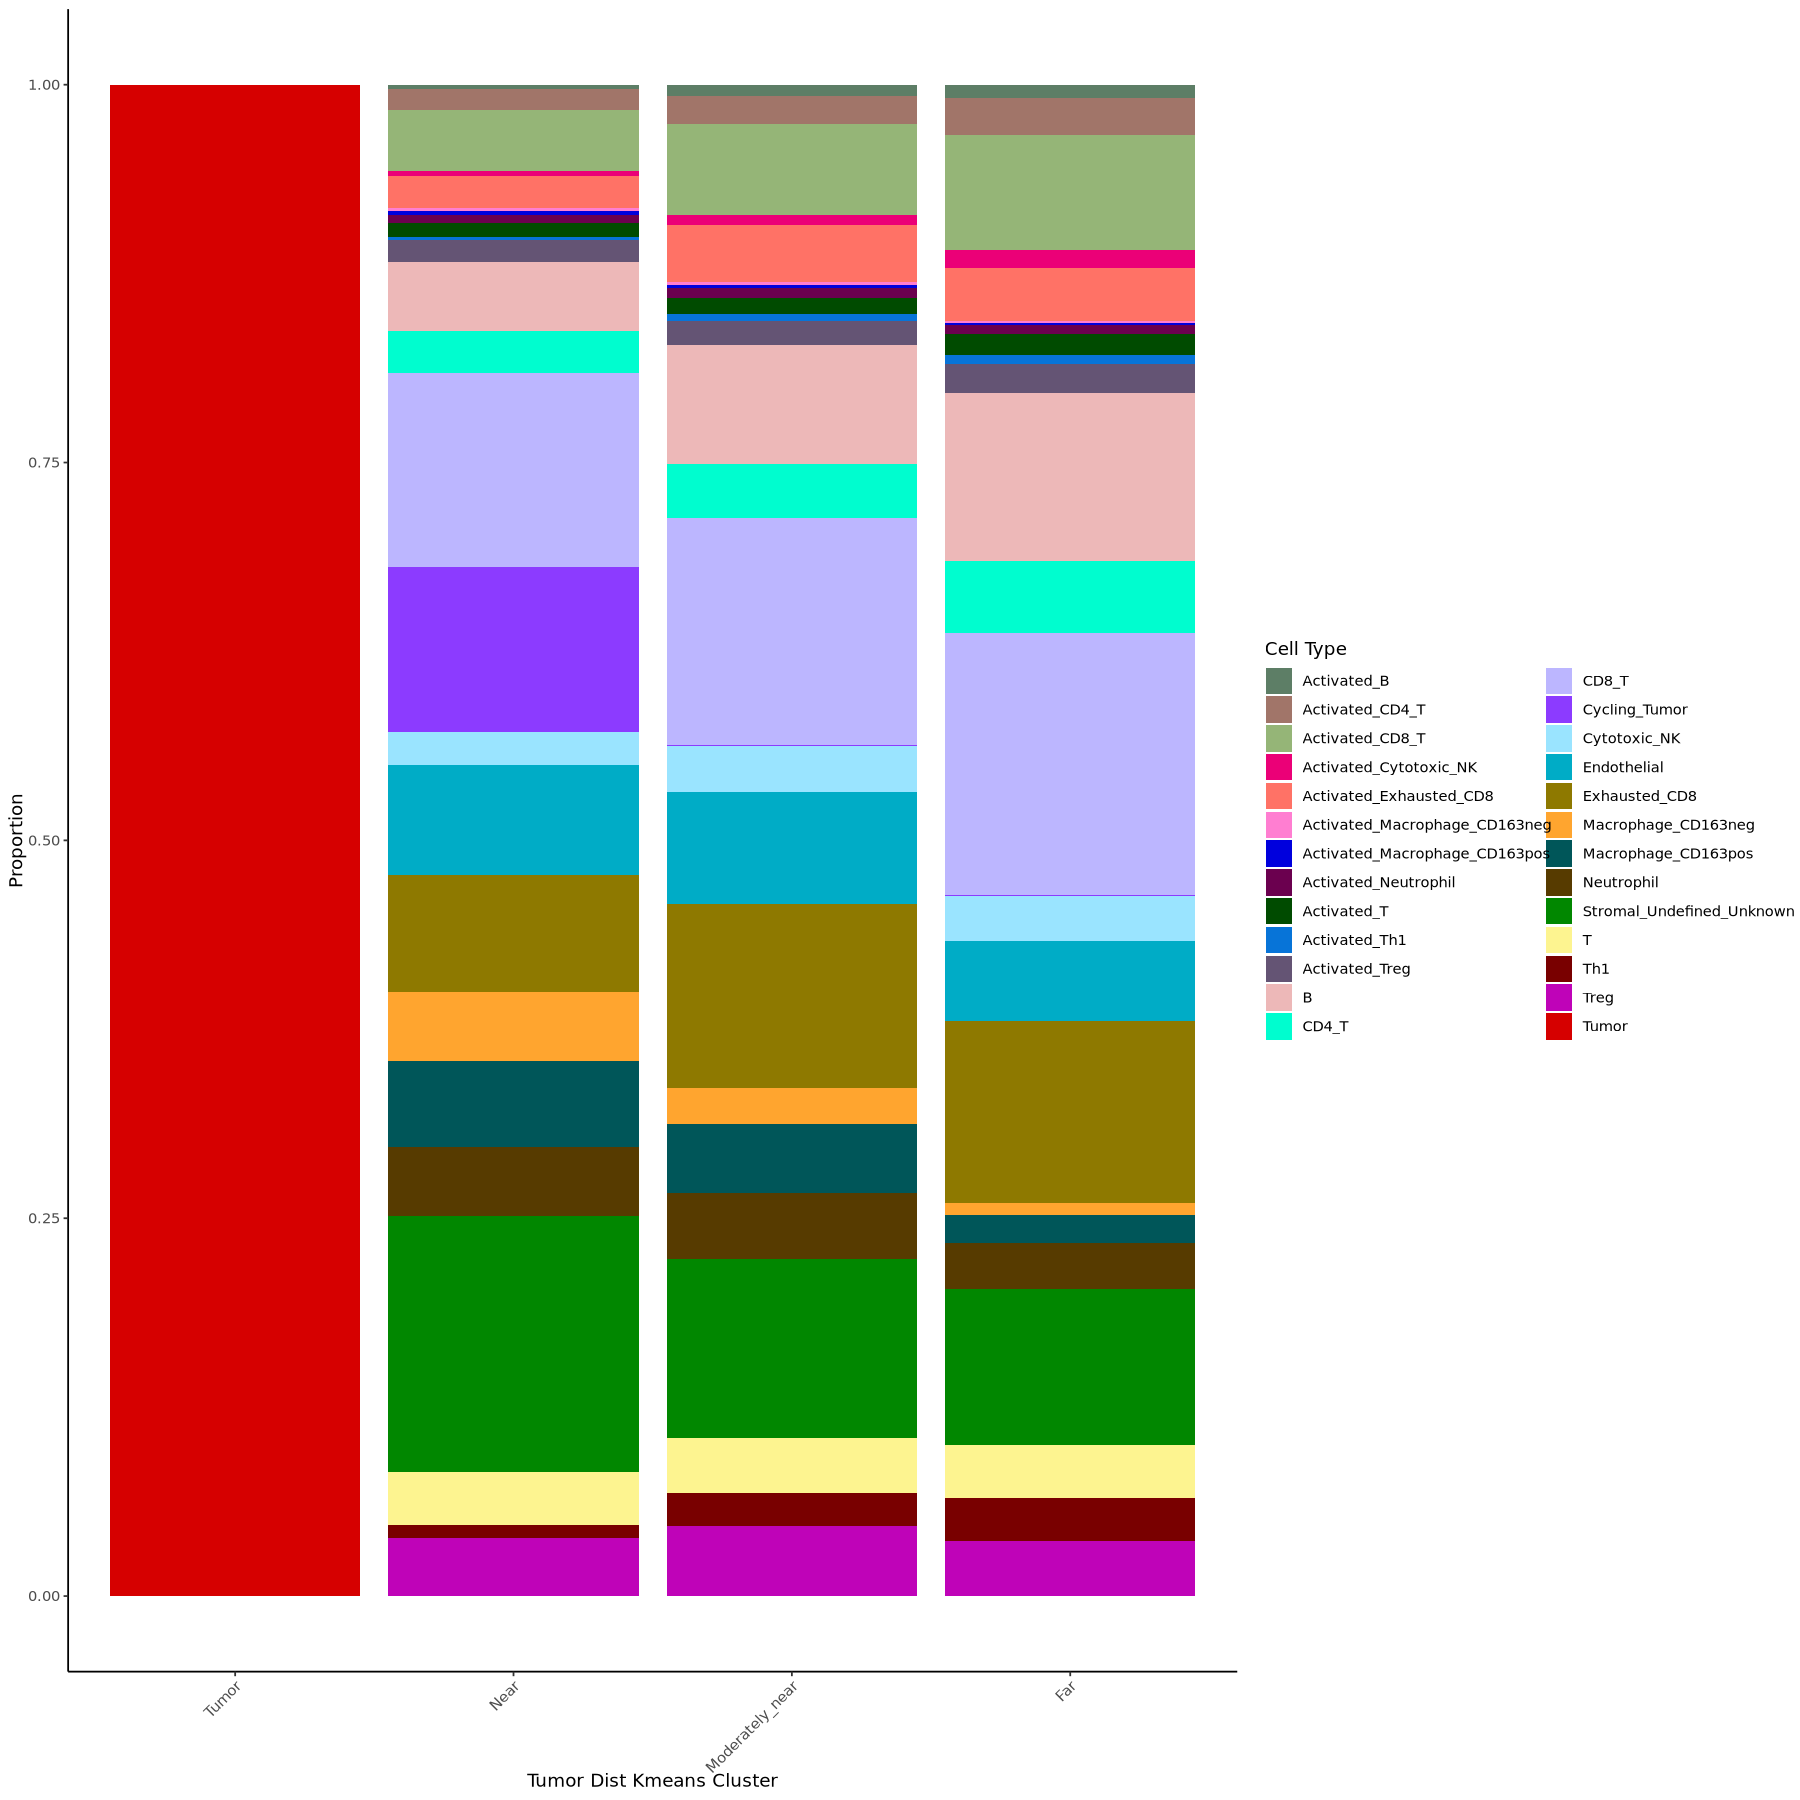

In [ ]:
library(dplyr)
library(reshape2)
library(ggplot2)

cell_type_colors <- c(
  Tumor = "#D60000",                        # from CHOL
  Cycling_Tumor = "#8C3BFF",                # from HNSC
  Stromal_Undefined_Unknown = "#018700",    # from KIRP
  Endothelial = "#00ACC6",                  # from PCPG
  Activated_Endothelial = "#97FF00",        # from GBM
  Neutrophil = "#573B00",                   # from LUAD
  Activated_Neutrophil = "#6B004F",         # from COADREAD
  Macrophage_CD163neg = "#FFA52F",          # from LAML
  Activated_Macrophage_CD163neg = "#FF7ED1",# from LUSC
  Macrophage_CD163pos = "#005659",          # from LUNG
  Activated_Macrophage_CD163pos = "#0000DD",# from PAAD
  CD4_T = "#00FDCF",                        # from SKCM
  Activated_CD4_T = "#A17569",              # from SARC
  CD8_T = "#BCB6FF",                        # from LGG
  Activated_CD8_T = "#95B577",              # from READ
  Treg = "#BF03B8",                         # from BLCA
  Activated_Treg = "#645474",              # from DLBC
  Th1 = "#790000",                          # from PRAD
  Activated_Th1 = "#0774D8",                # from GBMLGG
  T = "#FDF490",                            # from MESO
  Activated_T = "#004B00",                  # from KIRC
  Exhausted_CD8 = "#8E7900",                # from UCEC
  Activated_Exhausted_CD8 = "#FF7266",      # from BRCA
  B = "#EDB8B8",                            # from ESCA
  Activated_B = "#5D7E66",                  # from OV
  Cytotoxic_NK = "#9AE4FF",                 # from TGCT
  Activated_Cytotoxic_NK = "#EB0077"        # from UVM
)

# Create the contingency table and melt it
gplot_mat <- table(chosen_sample$Fine.cell.type, chosen_sample$Tumor_dist_kmeans) %>% 
  melt() %>%
  rename(CellType = Var1, KmeansCluster = Var2, Count = value)

# Plot stacked proportional bars with custom colors
ggplot(gplot_mat, aes(x = KmeansCluster, y = Count, fill = CellType)) +
  geom_bar(stat = "identity", position = "fill") +  # position = "fill" makes proportions
  scale_fill_manual(values = cell_type_colors) +    # add custom color palette here
  theme_classic() +
  labs(x = "Tumor Dist Kmeans Cluster", y = "Proportion", fill = "Cell Type") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

In [109]:
table(chosen_sample$Fine.cell.type)


                  Activated_B               Activated_CD4_T 
                          698                          2317 
              Activated_CD8_T        Activated_Cytotoxic_NK 
                         7235                           744 
      Activated_Exhausted_CD8 Activated_Macrophage_CD163neg 
                         3970                           307 
Activated_Macrophage_CD163pos          Activated_Neutrophil 
                          378                           829 
                  Activated_T                 Activated_Th1 
                         1520                           410 
               Activated_Treg                             B 
                         2298                          8830 
                        CD4_T                         CD8_T 
                         4658                         20681 
                Cycling_Tumor                  Cytotoxic_NK 
                        11063                          3676 
                  Endot

In [22]:
mat_mean_dist<-matrix(ncol=length(unique(obj$prelim_cell_type))+5, nrow=length(unique(obj$prelim_cell_type))+5)
rownames(mat_mean_dist)<-c(levels(obj$prelim_cell_type), "Activated_CD8_T", "Activated_CD4_T","IDO1_tumor","Cycling_tumor", "TIM3_tumor")
colnames(mat_mean_dist)<-c(levels(obj$prelim_cell_type), "Activated_CD8_T", "Activated_CD4_T","IDO1_tumor","Cycling_tumor", "TIM3_tumor")
mat_mean_dist[]<-0


In [118]:
mat_mean_dist


,B,CD4_T,CD8_T,Endothelial,Macrophage,Neutrophil,Stromal_Undefined,Th1,Treg,Tumor,Activated_CD8_T,Activated_CD4_T,IDO1_tumor,Cycling_tumor,TIM3_tumor
B,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CD4_T,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
CD8_T,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Endothelial,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Macrophage,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Neutrophil,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Stromal_Undefined,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Th1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Treg,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Tumor,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [23]:
for(x in 1:length(unique(obj$prelim_cell_type))){
  for(y in 1:length(unique(obj$prelim_cell_type))){
    if(x!=y){
        mat_mean_dist[x,y]<-mean(coords[,paste0("r_dist_",levels(obj$prelim_cell_type)[x])][obj$prelim_cell_type==levels(obj$prelim_cell_type)[y]])
    }
}
}

In [24]:
interest_cells<-c("Activated_CD8_T", "Activated_CD4_T","IDO1_tumor","Cycling_tumor", "TIM3_tumor")
for(x in 1:length(interest_cells)){
  for(y in 1:length(interest_cells)){
    if(x!=y){
        mat_mean_dist[x+length(levels(obj$prelim_cell_type)),y+length(levels(obj$prelim_cell_type))]<-mean(coords[,paste0("r_dist_",interest_cells[x])][obj$detailed_cell_type==interest_cells[y]])
    }
}
}


In [32]:
for(x in 1:length(unique(obj$prelim_cell_type))){
  for(y in 1:length(interest_cells)){
        mat_mean_dist[x,y+length(levels(obj$prelim_cell_type))]<-mean(coords[,paste0("r_dist_",levels(obj$prelim_cell_type)[x])][obj$detailed_cell_type==interest_cells[y]])
}
}

In [33]:
for(y in 1:length(unique(obj$prelim_cell_type))){
  for(x in 1:length(interest_cells)){
        mat_mean_dist[x+length(levels(obj$prelim_cell_type)),y]<-mean(coords[,paste0("r_dist_",interest_cells[x])][obj$prelim_cell_type==levels(obj$prelim_cell_type)[y]])
}
}

In [27]:
mean(coords[,paste0("r_dist_",interest_cells[x])][obj$prelim_cell_type==interest_cells[y]])

[1] NA

In [30]:
head(ggplot_mat)

,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,B,B,0.000000
2,CD4_T,B,11.413875
3,CD8_T,B,9.706597
4,Endothelial,B,61.194266
5,Macrophage,B,56.310944
6,Neutrophil,B,108.896358


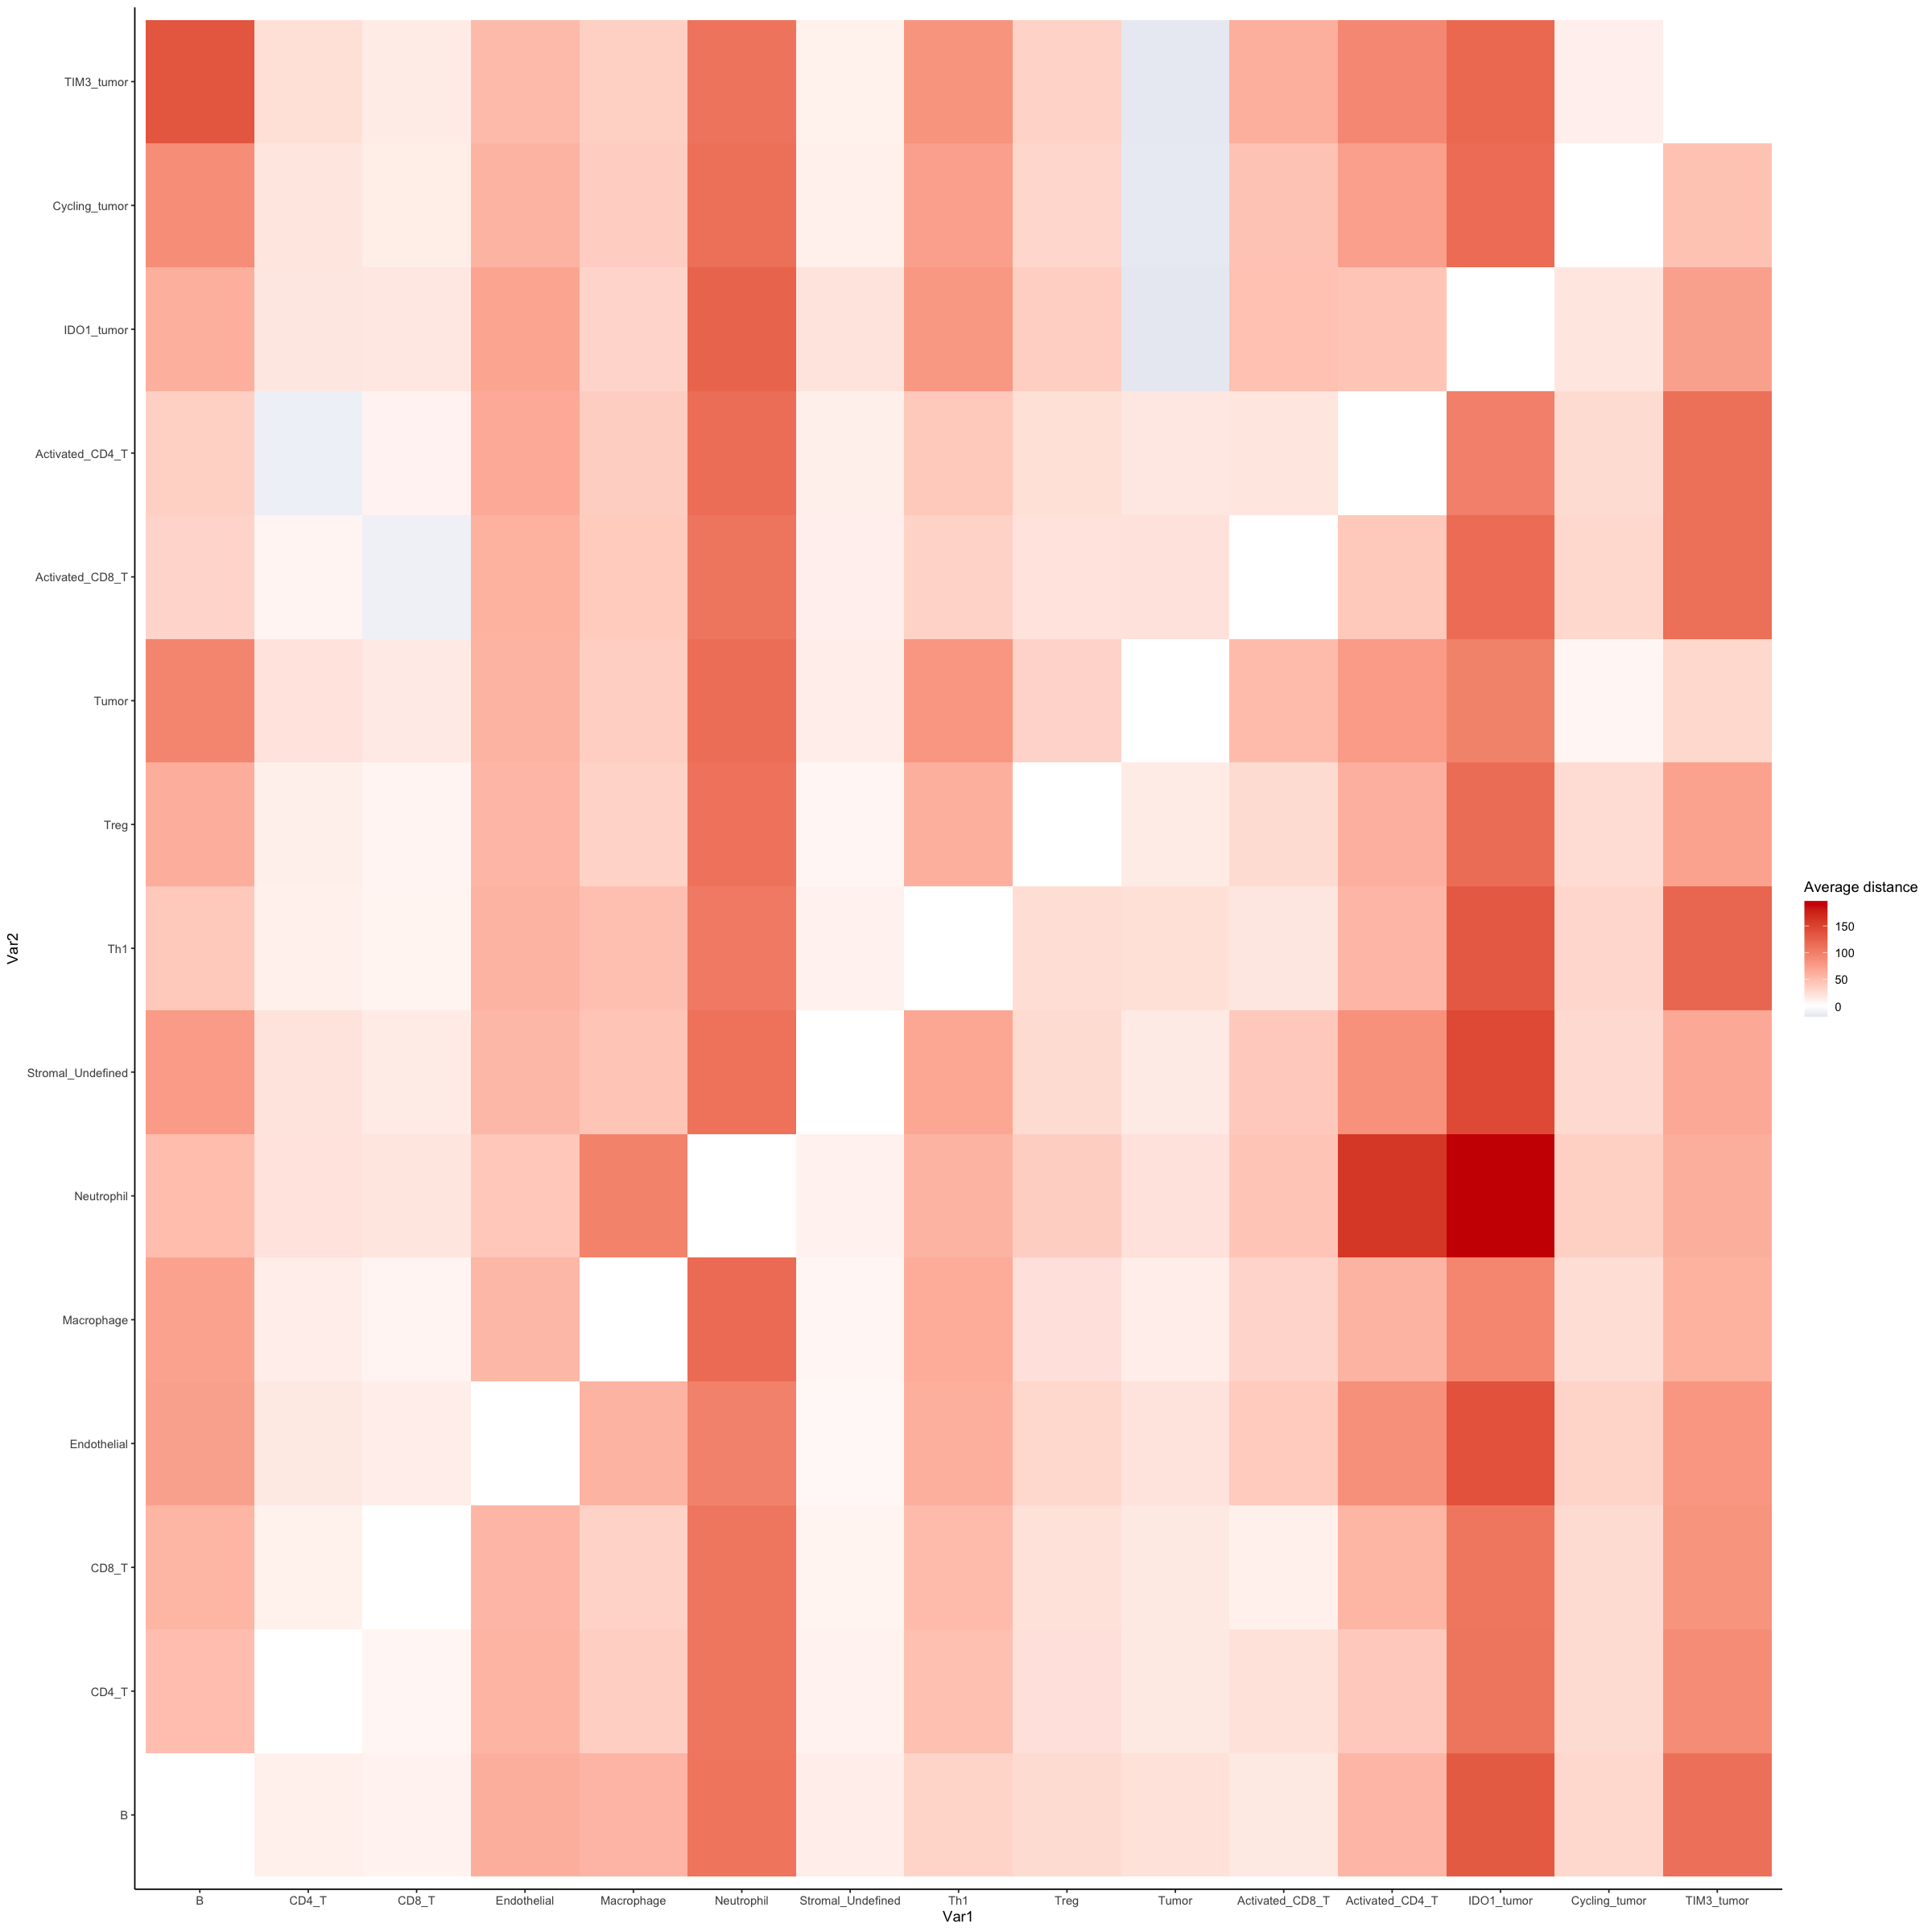

In [34]:
options(repr.plot.width=20, repr.plot.height=20)
ggplot_mat<-reshape2::melt(mat_mean_dist)
ggplot(ggplot_mat, aes(x=Var1, y=Var2, fill=value)) + geom_tile() + theme_classic() +scale_fill_gradient2(low="dodgerblue4", high="red3", mid="white") + labs(fill="Average distance") 

In [23]:
obj.list<-list()
for(x in c("20250225-Jharna-10103-A1_Scan1.er", "20250305-Jharna-34933-A1_Scan1.er", "20250318-Jharna-28873-A1_Scan1.er")){
    obj.list[[x]]<-readRDS(paste0('/Users/lindaprocell/Desktop/',x,'_singlecellexperiment.rds'))
}

In [137]:
obj.list<-lapply(obj.list, function(se){
    se<-as.Seurat(se, counts = "counts",data = NULL)
    return(se)
})

In [138]:
obj.list<-lapply(obj.list, function(se){
se <- NormalizeData(se, normalization.method = "CLR", margin = 2)
se <- ScaleData(se)
VariableFeatures(se) <- rownames(se)  # since the panel is small, treat all features as variable.
se <- RunPCA(se, npcs = 15, verbose = FALSE)
#se <- RunUMAP(se, dims = 1:20, verbose = FALSE)
se <- FindNeighbors(se, dims = 1:15, verbose = FALSE)
se <- FindClusters(se, verbose = FALSE, resolution = 0.4, n.start = 1)
})

Normalizing across cells

Centering and scaling data matrix

Normalizing across cells

Centering and scaling data matrix

Normalizing across cells

Centering and scaling data matrix



In [ ]:
DimPlot(obj.list[[1]], group.by = "seurat_clusters")

In [1]:
ls()

character(0)